In [45]:

# PANEL DATA ANALYSIS - ICT INDEX AND SERVICE EXPORTS


import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [46]:
# STEP 1: LOAD & CLEAN DATA 
df = pd.read_csv("C:/Users/Admin/Desktop/ICT.csv")
df


,Country,Year,Service_export,Internet_users,Mobile_cellular_subscriptions,Fixed_broadband,GDP,Population
0,India,2009,20.40051937,5.12,42.8461,0.632032,1155.101633,1225524753
1,India,2010,22.40093325,7.5,60.4906,0.883809,1235.159391,1243481564
2,India,2011,24.54041132,10.07,70.8726,1.05859,1281.610544,1261224954
3,India,2012,24.53443066,11.1,67.6264,1.1717,1333.096266,1278674502
4,India,2013,25.4308613,12.3,68.3967,1.15198,1399.453798,1295829511
...,...,...,...,...,...,...,...,...
270,United Arab Emirates,2015,96.82780563,90.5,206.839,14.2305,43534.997270,8505237
271,United Arab Emirates,2016,97.66312109,90.6,220.412,14.3683,43745.288170,8935095
272,United Arab Emirates,2017,97.85430603,94.8199,214.701,29.9083,42690.214780,9223225
273,United Arab Emirates,2018,93.71698102,98.45,214.842,32.3591,42679.751910,9346701


In [47]:
# standardize column names
df.columns = df.columns.str.lower().str.strip()
print("Columns found:", df.columns.tolist())

Columns found: ['country', 'year', 'service_export', 'internet_users', 'mobile_cellular_subscriptions', 'fixed_broadband', 'gdp', 'population']


In [48]:
# required columns
required_cols = ['country', 'year', 'service_export', 
                 'internet_users', 'mobile_cellular_subscriptions', 
                 'fixed_broadband', 'gdp', 'population']

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")


In [49]:
# sort and handle duplicates
df = df[required_cols].drop_duplicates().sort_values(['country', 'year'])
df

,country,year,service_export,internet_users,mobile_cellular_subscriptions,fixed_broadband,gdp,population
198,Argentina,2009,19.56098506,34,128.462,8.59391,12285.378470,40854831
199,Argentina,2010,18.93382341,45,138.252,9.75627,13387.155370,41288694
200,Argentina,2011,18.44920915,51,145.511,10.956,14040.618910,41730660
201,Argentina,2012,16.23785946,55.8,152.574,12.2115,13754.425420,42161721
202,Argentina,2013,14.61717339,59.9,158.191,14.6798,13946.095080,42582455
...,...,...,...,...,...,...,...,...
83,Viet Nam,2015,72.92285184,45,129.627,8.24968,2577.568853,92823254
84,Viet Nam,2016,74.10728626,53,128.298,9.67902,2715.578874,94000117
85,Viet Nam,2017,81.76252184,58.14,126.098,11.841,2868.136800,95176977
86,Viet Nam,2018,84.42345608,69.8479,146.138,13.5025,3048.283276,96237319


In [50]:
num_vars = ['service_export', 'internet_users', 'mobile_cellular_subscriptions', 
            'fixed_broadband', 'gdp', 'population']

df[num_vars] = df.groupby('country')[num_vars].transform(lambda g: g.interpolate().ffill().bfill())
df[num_vars]

C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\4279983058.py:4: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[num_vars] = df.groupby('country')[num_vars].transform(lambda g: g.interpolate().ffill().bfill())
C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\4279983058.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[num_vars] = df.groupby('country')[num_vars].transform(lambda g: g.interpolate().ffill().bfill())
C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\4279983058.py:4: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[num_vars] = df.groupby('country')[num_vars].transform(lambda g: g.interpolate().ffi

,service_export,internet_users,mobile_cellular_subscriptions,fixed_broadband,gdp,population
198,19.56098506,34,128.462,8.59391,12285.378470,40854831
199,18.93382341,45,138.252,9.75627,13387.155370,41288694
200,18.44920915,51,145.511,10.956,14040.618910,41730660
201,16.23785946,55.8,152.574,12.2115,13754.425420,42161721
202,14.61717339,59.9,158.191,14.6798,13946.095080,42582455
...,...,...,...,...,...,...
83,72.92285184,45,129.627,8.24968,2577.568853,92823254
84,74.10728626,53,128.298,9.67902,2715.578874,94000117
85,81.76252184,58.14,126.098,11.841,2868.136800,95176977
86,84.42345608,69.8479,146.138,13.5025,3048.283276,96237319


In [51]:
num_vars = ['service_export', 'internet_users', 'mobile_cellular_subscriptions', 
            'fixed_broadband', 'gdp', 'population']

#  Ensure all numeric columns are actually numeric
df[num_vars] = df[num_vars].apply(pd.to_numeric, errors='coerce')

# Fill missing values with country-wise interpolation
df[num_vars] = df.groupby('country')[num_vars].transform(lambda g: g.interpolate().ffill().bfill())

#  Fill any remaining NaN values with the column mean
df[num_vars] = df[num_vars].fillna(df[num_vars].mean())

#  Check missing values
print("\nMissing values after cleaning:\n", df[num_vars].isna().sum())



Missing values after cleaning:
 service_export                   0
internet_users                   0
mobile_cellular_subscriptions    0
fixed_broadband                  0
gdp                              0
population                       0
dtype: int64


In [52]:

# CREATE ICT INDEX (Simple Average)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[['internet_users', 'mobile_cellular_subscriptions', 'fixed_broadband']])
df[['int_scaled', 'mob_scaled', 'broad_scaled']] = scaled
df['ict_index'] = df[['int_scaled', 'mob_scaled', 'broad_scaled']].mean(axis=1)
df['ict_index']

198    0.392581
199    0.456816
200    0.500624
201    0.540645
202    0.588515
         ...   
83     0.428031
84     0.467691
85     0.503858
86     0.591441
87     0.596009
Name: ict_index, Length: 275, dtype: float64

In [53]:

# LOG TRANSFORM VARIABLES

eps = 1e-6
df['log_service_export'] = np.log(df['service_export'] + eps)
df['log_gdp'] = np.log(df['gdp'] + eps)
df['log_population'] = np.log(df['population'] + eps)

In [54]:

# DESCRIPTIVE STATISTICS

desc = df[['log_service_export', 'ict_index', 'log_gdp', 'log_population']].describe().T
print("\n--- DESCRIPTIVE STATISTICS ---\n", desc)



--- DESCRIPTIVE STATISTICS ---
                     count       mean       std        min        25%  \
log_service_export  275.0   3.274247  0.602767   2.032006   2.882474   
ict_index           275.0   0.378460  0.189174   0.000000   0.234189   
log_gdp             275.0   8.430675  1.002980   5.994133   7.686177   
log_population      275.0  18.072658  1.218879  15.718671  17.217909   

                          50%        75%        max  
log_service_export   3.236354   3.550630   4.585045  
ict_index            0.373473   0.516530   0.987786  
log_gdp              8.550124   9.146111  10.687393  
log_population      17.833601  18.626266  21.065255  


In [55]:

# CORRELATION MATRIX

corr = df[['log_service_export', 'ict_index', 'log_gdp', 'log_population']].corr().round(3)
print("\n--- CORRELATION MATRIX ---\n", corr)



--- CORRELATION MATRIX ---
                     log_service_export  ict_index  log_gdp  log_population
log_service_export               1.000      0.495    0.484          -0.424
ict_index                        0.495      1.000    0.880          -0.371
log_gdp                          0.484      0.880    1.000          -0.429
log_population                  -0.424     -0.371   -0.429           1.000


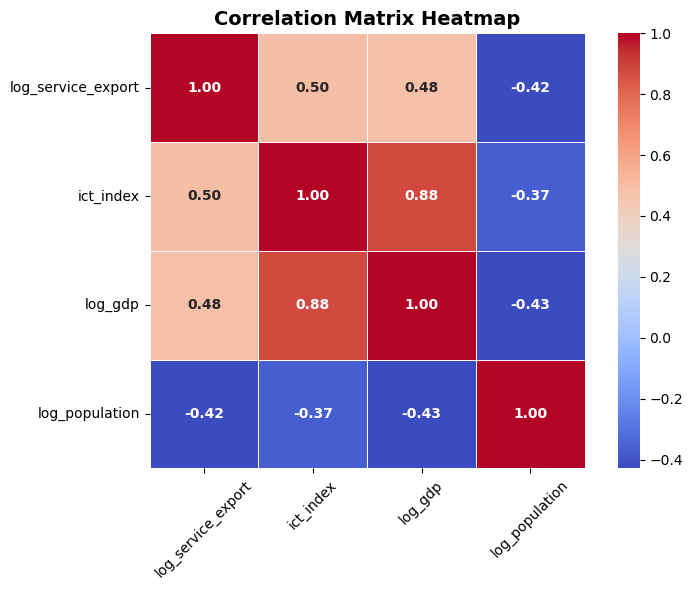

In [98]:

# CORRELATION MATRIX HEATMAP (VISUALIZATION)


import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation again (in case variables are updated)
corr = df[['log_service_export', 'ict_index', 'log_gdp', 'log_population']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True,
            annot_kws={"size": 10, "weight": "bold"}, square=True)
plt.title("Correlation Matrix Heatmap", fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:

# PANEL DATA SETUP

df = df.set_index(['country', 'year'])
y = df['log_service_export']
X = df[['ict_index', 'log_gdp', 'log_population']]

In [57]:

# FIXED EFFECTS MODEL
fe_model = PanelOLS(y, X, entity_effects=True)
fe_res = fe_model.fit(cov_type='robust')
print("\n--- FIXED EFFECTS MODEL ---\n", fe_res.summary)


--- FIXED EFFECTS MODEL ---
                           PanelOLS Estimation Summary                           
Dep. Variable:     log_service_export   R-squared:                        0.2529
Estimator:                   PanelOLS   R-squared (Between):             -70.226
No. Observations:                 275   R-squared (Within):               0.2529
Date:                Mon, Oct 27 2025   R-squared (Overall):             -70.090
Time:                        09:15:26   Log-likelihood                    178.73
Cov. Estimator:                Robust                                           
                                        F-statistic:                      27.865
Entities:                          25   P-value                           0.0000
Avg Obs:                       11.000   Distribution:                   F(3,247)
Min Obs:                       11.000                                           
Max Obs:                       11.000   F-statistic (robust):             20.63

In [58]:

# RANDOM EFFECTS MODEL

re_model = RandomEffects(y, X)
re_res = re_model.fit(cov_type='robust')
print("\n--- RANDOM EFFECTS MODEL ---\n", re_res.summary)


--- RANDOM EFFECTS MODEL ---
                         RandomEffects Estimation Summary                        
Dep. Variable:     log_service_export   R-squared:                        0.7216
Estimator:              RandomEffects   R-squared (Between):              0.9553
No. Observations:                 275   R-squared (Within):               0.0390
Date:                Mon, Oct 27 2025   R-squared (Overall):              0.9535
Time:                        09:15:40   Log-likelihood                    126.59
Cov. Estimator:                Robust                                           
                                        F-statistic:                      234.98
Entities:                          25   P-value                           0.0000
Avg Obs:                       11.000   Distribution:                   F(3,272)
Min Obs:                       11.000                                           
Max Obs:                       11.000   F-statistic (robust):             245.

In [59]:

# HAUSMAN TEST

def hausman(fe, re):
    b = fe.params - re.params
    v = fe.cov - re.cov
    stat = float(b.T @ np.linalg.inv(v) @ b)
    pval = 1 - stats.chi2.cdf(stat, len(b))
    return stat, pval

try:
    h, p = hausman(fe_res, re_res)
    print(f"\nHausman Test → χ² = {h:.3f}, p-value = {p:.4f}")
    if p < 0.05:
        print("Fixed Effects preferred")
    else:
        print(" Random Effects preferred")
except:
    print("\n Hausman test could not be computed (matrix singular).")


Hausman Test → χ² = 74.469, p-value = 0.0000
✅ Fixed Effects preferred


In [60]:

# STATIONARITY TEST (ADF)

def adf_check(series):
    result = adfuller(series.dropna())
    return round(result[1], 4)

print("\n--- ADF TEST (Stationarity) ---")
for var in ['log_service_export', 'ict_index', 'log_gdp', 'log_population']:
    pvals = df.groupby('country')[var].apply(adf_check)
    print(f"{var}: Avg p-value across countries = {pvals.mean():.4f}")

# STEP 11: AUTOCORRELATION (DURBIN-WATSON)

dw = durbin_watson(fe_res.resids)
print("\nDurbin-Watson Statistic (FE residuals):", round(dw, 3))


# STEP 12: MULTICOLLINEARITY (VIF)

X_vif = sm.add_constant(X)
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n--- VARIANCE INFLATION FACTOR (VIF) ---\n", vif)

# STEP 13: HETEROSKEDASTICITY (BREUSCH-PAGAN)

pooled_ols = sm.OLS(y, sm.add_constant(X)).fit()
bp_test = het_breuschpagan(pooled_ols.resid, pooled_ols.model.exog)
bp_labels = ['LM Stat', 'LM p-value', 'F Stat', 'F p-value']
print("\n--- BREUSCH-PAGAN TEST ---\n", dict(zip(bp_labels, bp_test)))

print("\n Analysis Complete.")


--- ADF TEST (Stationarity) ---
log_service_export: Avg p-value across countries = 0.5925
ict_index: Avg p-value across countries = 0.5358
log_gdp: Avg p-value across countries = 0.4330
log_population: Avg p-value across countries = 0.5444

Durbin-Watson Statistic (FE residuals): 0.765

--- VARIANCE INFLATION FACTOR (VIF) ---
          Variable         VIF
0           const  626.066188
1       ict_index    4.417706
2         log_gdp    4.670276
3  log_population    1.225806

--- BREUSCH-PAGAN TEST ---
 {'LM Stat': 20.473668986497753, 'LM p-value': 0.00013538700980432174, 'F Stat': 7.266261049492435, 'F p-value': 0.0001050358781696613}

✅ Analysis Complete.


In [42]:
df

service_export  internet_users  mobile_cellular_subscriptions  \
country   year                                                                  
Argentina 2009       19.560985         34.0000                        128.462   
          2010       18.933823         45.0000                        138.252   
          2011       18.449209         51.0000                        145.511   
          2012       16.237859         55.8000                        152.574   
          2013       14.617173         59.9000                        158.191   
...                        ...             ...                            ...   
Viet Nam  2015       72.922852         45.0000                        129.627   
          2016       74.107286         53.0000                        128.298   
          2017       81.762522         58.1400                        126.098   
          2018       84.423456         69.8479                        146.138   
          2019       85.157587         68.6616                        140.193   

                fixed_broadband           gdp  population  int_scaled  \
country   year                                                          
Argentina 2009          8.59391  12285.378470    40854831    0.339316   
          2010          9.75627  13387.155370    41288694    0.450867   
          2011         10.95600  14040.618910    41730660    0.511713   
          2012         12.21150  13754.425420    42161721    0.560389   
          2013         14.67980  13946.095080    42582455    0.601967   
...                         ...           ...         ...         ...   
Viet Nam  2015          8.24968   2577.568853    92823254    0.450867   
          2016          9.67902   2715.578874    94000117    0.531995   
          2017         11.84100   2868.136800    95176977    0.584119   
          2018         13.50250   3048.283276    96237319    0.702849   
          2019         15.23290   3241.076490    97173776    0.690818   

                mob_scaled  broad_scaled  ict_index  log_service_export  \
country   year                                                            
Argentina 2009    0.573927      0.264498   0.392581            2.973537   
          2010    0.619292      0.300289   0.456816            2.940950   
          2011    0.652928      0.337231   0.500624            2.915022   
          2012    0.685656      0.375890   0.540645            2.787346   
          2013    0.711684      0.451893   0.588515            2.682197   
...                    ...           ...        ...                 ...   
Viet Nam  2015    0.579326      0.253899   0.428031            4.289402   
          2016    0.573167      0.297911   0.467691            4.305514   
          2017    0.562973      0.364482   0.503858            4.403819   
          2018    0.655833      0.415642   0.591441            4.435845   
          2019    0.628286      0.468924   0.596009            4.444504   

                 log_gdp  log_population  
country   year                            
Argentina 2009  9.416165       17.525536  
          2010  9.502051       17.536099  
          2011  9.549710       17.546747  
          2012  9.529116       17.557023  
          2013  9.542955       17.566953  
...                  ...             ...  
Viet Nam  2015  7.854602       18.346208  
          2016  7.906760       18.358807  
          2017  7.961418       18.371249  
          2018  8.022334       18.382328  
          2019  8.083661       18.392011  

[275 rows x 13 columns]

In [69]:
import matplotlib.pyplot as plt

<Figure size 1200x600 with 0 Axes>

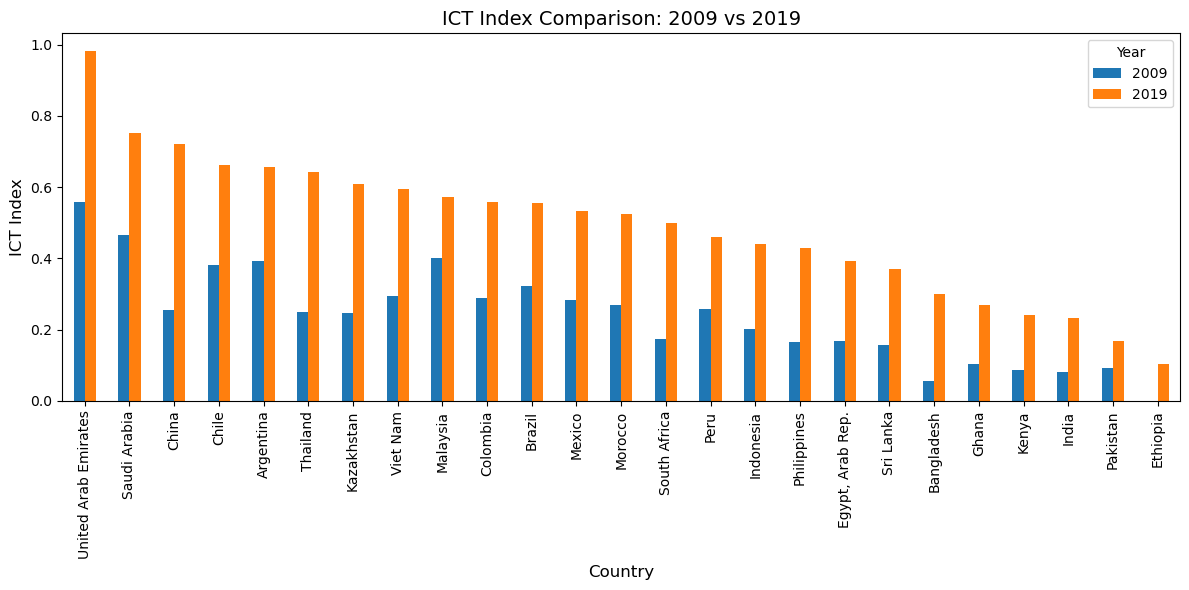

In [70]:

# GRAPH - ICT INDEX COMPARISON (2009 vs 2019)

df_reset = df.reset_index()
ict_compare = df_reset[df_reset['year'].isin([2009, 2019])]
ict_pivot = ict_compare.pivot(index='country', columns='year', values='ict_index').sort_values(by=2019, ascending=False)

plt.figure(figsize=(12,6))
ict_pivot.plot(kind='bar', figsize=(12,6))
plt.title("ICT Index Comparison: 2009 vs 2019", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("ICT Index", fontsize=12)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

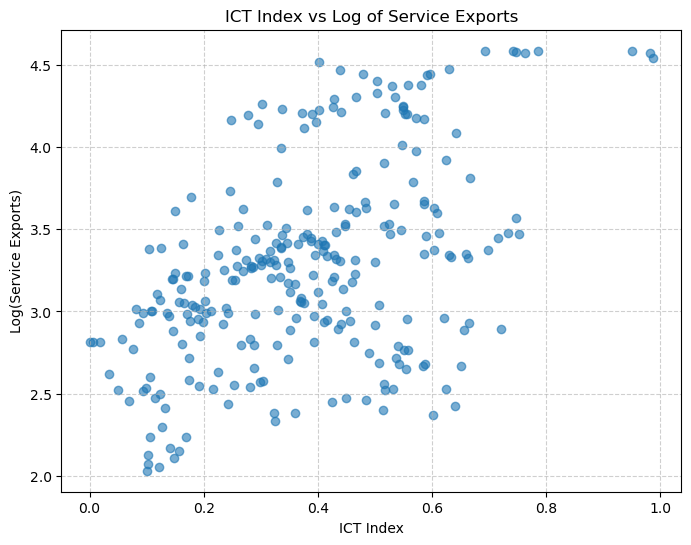

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(df_reset['ict_index'], df_reset['log_service_export'], alpha=0.6)
plt.title("ICT Index vs Log of Service Exports")
plt.xlabel("ICT Index")
plt.ylabel("Log(Service Exports)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\3438596627.py:1: RuntimeWarning: divide by zero encountered in scalar divide
  df_reset['ict_growth'] = df_reset.groupby('country')['ict_index'].transform(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100)


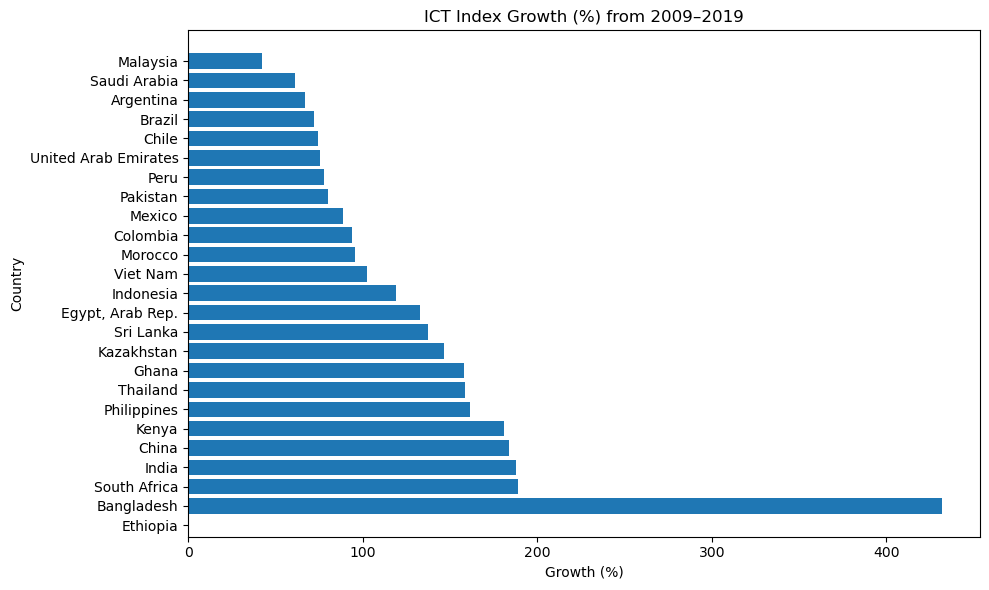

In [73]:
df_reset['ict_growth'] = df_reset.groupby('country')['ict_index'].transform(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100)
ict_growth = df_reset.drop_duplicates('country')[['country', 'ict_growth']].sort_values('ict_growth', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(ict_growth['country'], ict_growth['ict_growth'])
plt.title("ICT Index Growth (%) from 2009–2019")
plt.xlabel("Growth (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

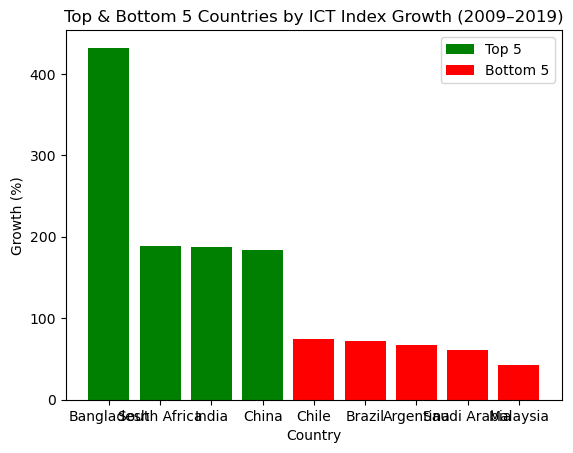

In [74]:
top5 = ict_growth.head(5)
bottom5 = ict_growth.tail(5)

plt.bar(top5['country'], top5['ict_growth'], color='green', label='Top 5')
plt.bar(bottom5['country'], bottom5['ict_growth'], color='red', label='Bottom 5')
plt.title("Top & Bottom 5 Countries by ICT Index Growth (2009–2019)")
plt.xlabel("Country")
plt.ylabel("Growth (%)")
plt.legend()
plt.show()

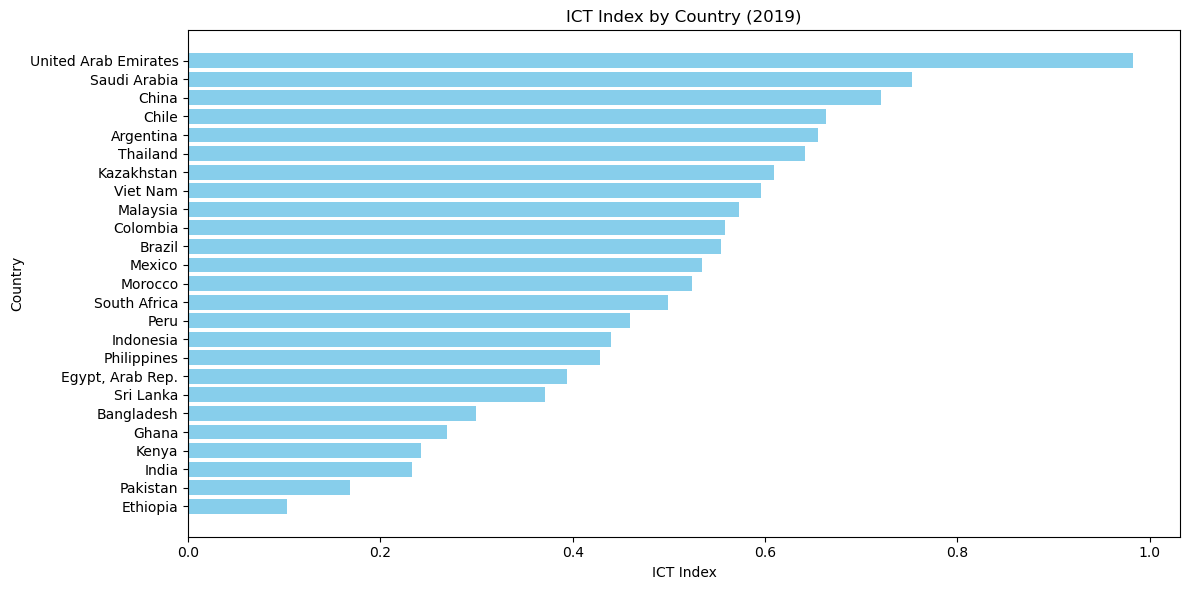


--- Top 5 ICT Leaders ---
                  country  ict_index
263  United Arab Emirates   0.982424
219          Saudi Arabia   0.753038
54                  China   0.721050
43                  Chile   0.663331
10              Argentina   0.655488

--- Bottom 5 ICT Performers ---
      country  ict_index
98      Ghana   0.269443
142     Kenya   0.242069
109     India   0.233020
186  Pakistan   0.168470
87   Ethiopia   0.102463


In [77]:
# --- ICT Index by Country (Latest Year, e.g., 2019) ---
latest_year = df_reset['year'].max()
ict_latest = df_reset[df_reset['year'] == latest_year][['country', 'ict_index']].sort_values(by='ict_index', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(ict_latest['country'], ict_latest['ict_index'], color='skyblue')
plt.title(f"ICT Index by Country ({latest_year})")
plt.xlabel("ICT Index")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- Top 5 ICT Leaders ---")
print(ict_latest.head(5))
print("\n--- Bottom 5 ICT Performers ---")
print(ict_latest.tail(5))


C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\896561497.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  lambda g: ((g[g['year']==2019]['ict_index'].values[0] - g[g['year']==2009]['ict_index'].values[0]) / g[g['year']==2009]['ict_index'].values[0]) * 100
C:\Users\Admin\AppData\Local\Temp\ipykernel_12792\896561497.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ict_growth = df_reset.groupby('country').apply(


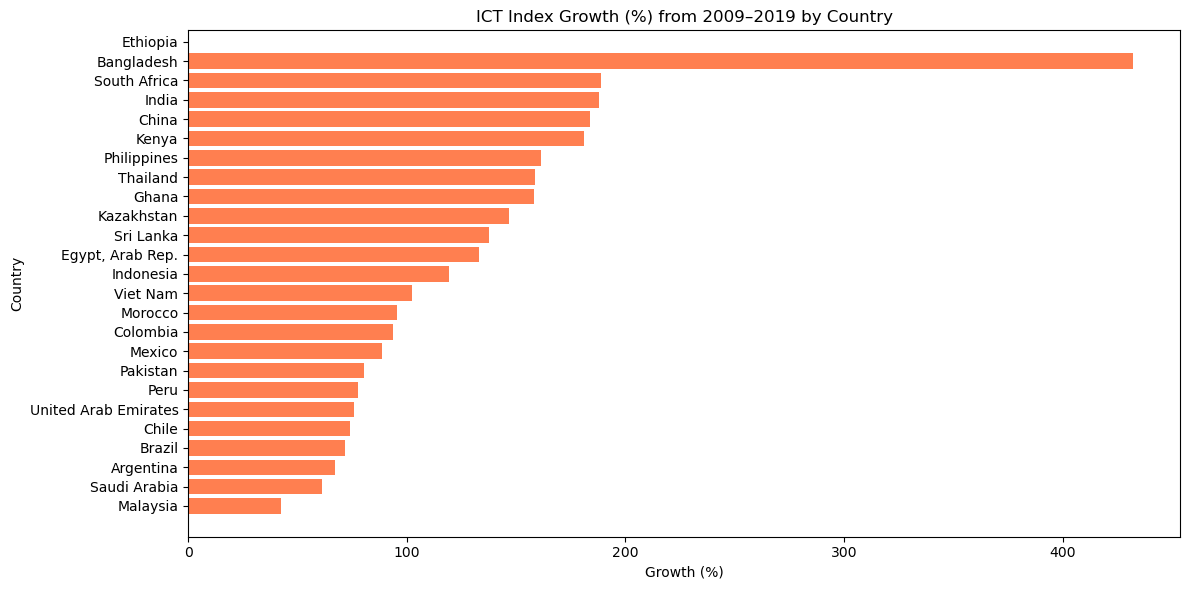


--- Top 5 Fastest ICT Growth Countries ---
         country  ict_growth
7       Ethiopia         inf
1     Bangladesh  432.014584
20  South Africa  188.698890
9          India  187.691230
4          China  183.682401

--- Bottom 5 Slowest ICT Growth Countries ---
         country  ict_growth
3          Chile   74.225274
2         Brazil   71.814799
0      Argentina   66.969109
19  Saudi Arabia   61.405838
13      Malaysia   42.356186


In [80]:
ict_growth = df_reset.groupby('country').apply(
    lambda g: ((g[g['year']==2019]['ict_index'].values[0] - g[g['year']==2009]['ict_index'].values[0]) / g[g['year']==2009]['ict_index'].values[0]) * 100
).reset_index(name='ict_growth')

ict_growth = ict_growth.sort_values('ict_growth', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(ict_growth['country'], ict_growth['ict_growth'], color='coral')
plt.title("ICT Index Growth (%) from 2009–2019 by Country")
plt.xlabel("Growth (%)")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- Top 5 Fastest ICT Growth Countries ---")
print(ict_growth.head(5))
print("\n--- Bottom 5 Slowest ICT Growth Countries ---")
print(ict_growth.tail(5))

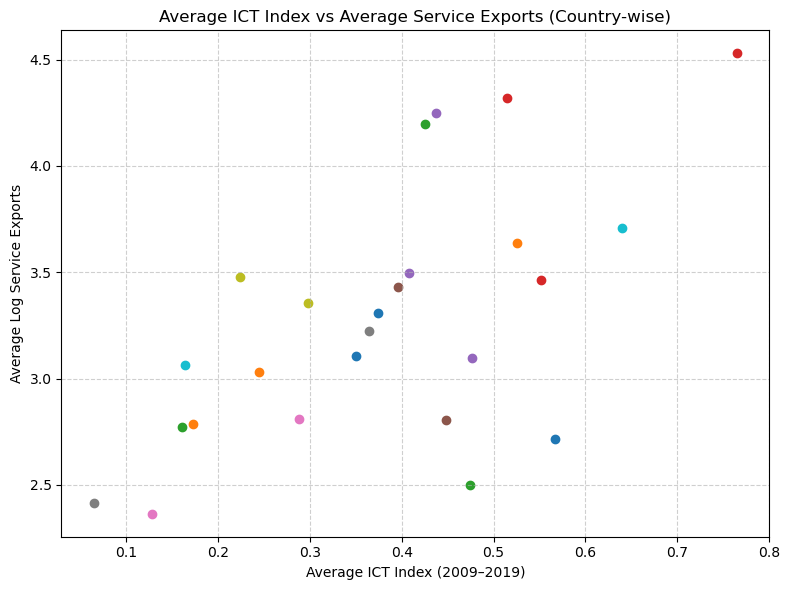

In [84]:
plt.figure(figsize=(8,6))
for country in df_reset['country'].unique():
    data = df_reset[df_reset['country'] == country]
    plt.scatter(data['ict_index'].mean(), data['log_service_export'].mean(), label=country)

plt.title("Average ICT Index vs Average Service Exports (Country-wise)")
plt.xlabel("Average ICT Index (2009–2019)")
plt.ylabel("Average Log Service Exports")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

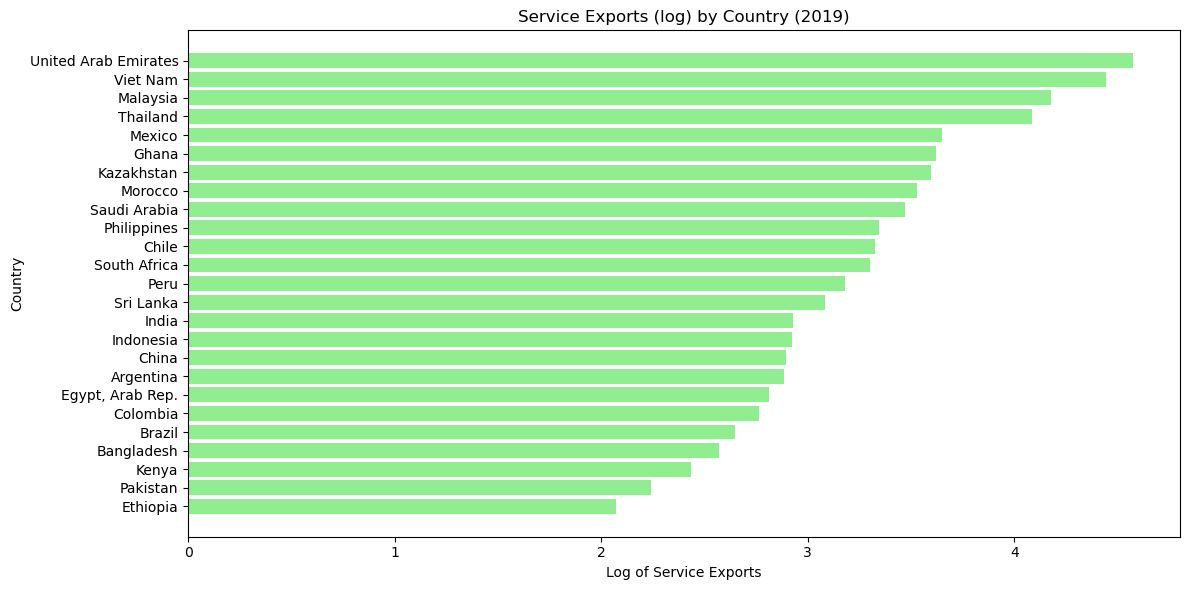


--- Top 5 Service Exporters ---
                  country  log_service_export
263  United Arab Emirates            4.573263
274              Viet Nam            4.444504
153              Malaysia            4.178652
252              Thailand            4.086294
164                Mexico            3.651428

--- Bottom 5 Service Exporters ---
        country  log_service_export
32       Brazil            2.647799
21   Bangladesh            2.572212
142       Kenya            2.436066
186    Pakistan            2.239737
87     Ethiopia            2.071909


In [86]:
service_latest = df_reset[df_reset['year'] == latest_year][['country', 'log_service_export']].sort_values(by='log_service_export', ascending=False)

plt.figure(figsize=(12,6))
plt.barh(service_latest['country'], service_latest['log_service_export'], color='lightgreen')
plt.title(f"Service Exports (log) by Country ({latest_year})")
plt.xlabel("Log of Service Exports")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- Top 5 Service Exporters ---")
print(service_latest.head(5))
print("\n--- Bottom 5 Service Exporters ---")
print(service_latest.tail(5))


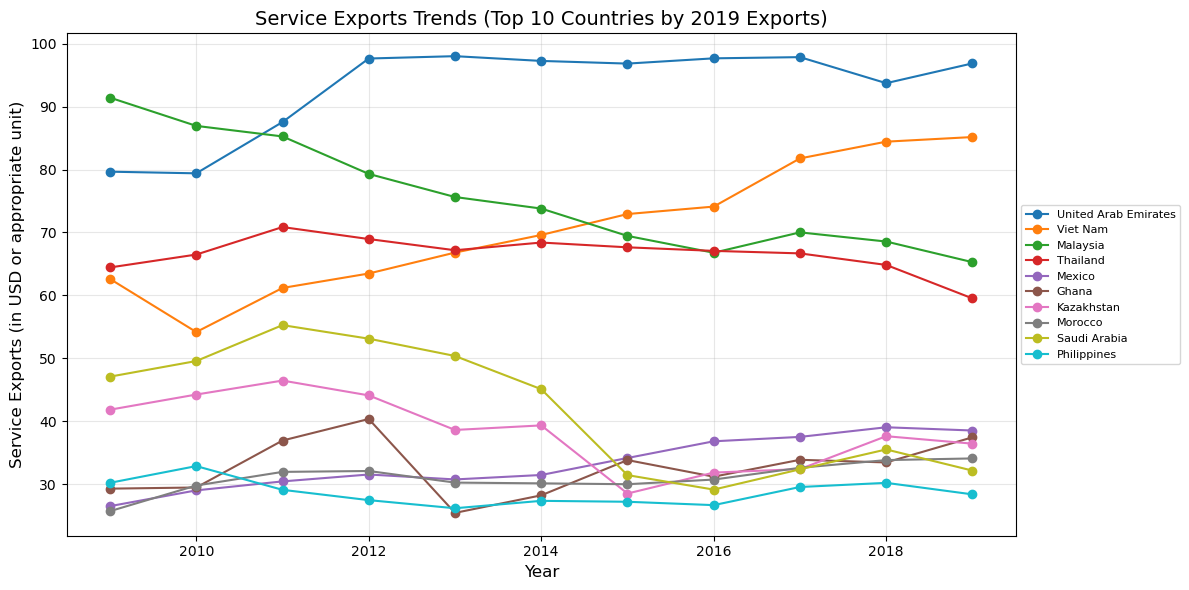

In [88]:

# SERVICE EXPORTS COMPARISON (COUNTRY-WISE OVER YEARS)

plt.figure(figsize=(12, 6))

# Option 1: Plot for all countries (can get crowded)
# sample_countries = df_reset['country'].unique()

# Option 2 (recommended): Plot for top 10 countries by 2019 service exports
top_countries = (
    df_reset[df_reset['year'] == 2019]
    .sort_values('service_export', ascending=False)['country']
    .head(10)
)

# Plot each country's trend
for country in top_countries:
    temp = df_reset[df_reset['country'] == country]
    plt.plot(temp['year'], temp['service_export'], marker='o', label=country)

plt.title("Service Exports Trends (Top 10 Countries by 2019 Exports)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Service Exports (in USD or appropriate unit)", fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

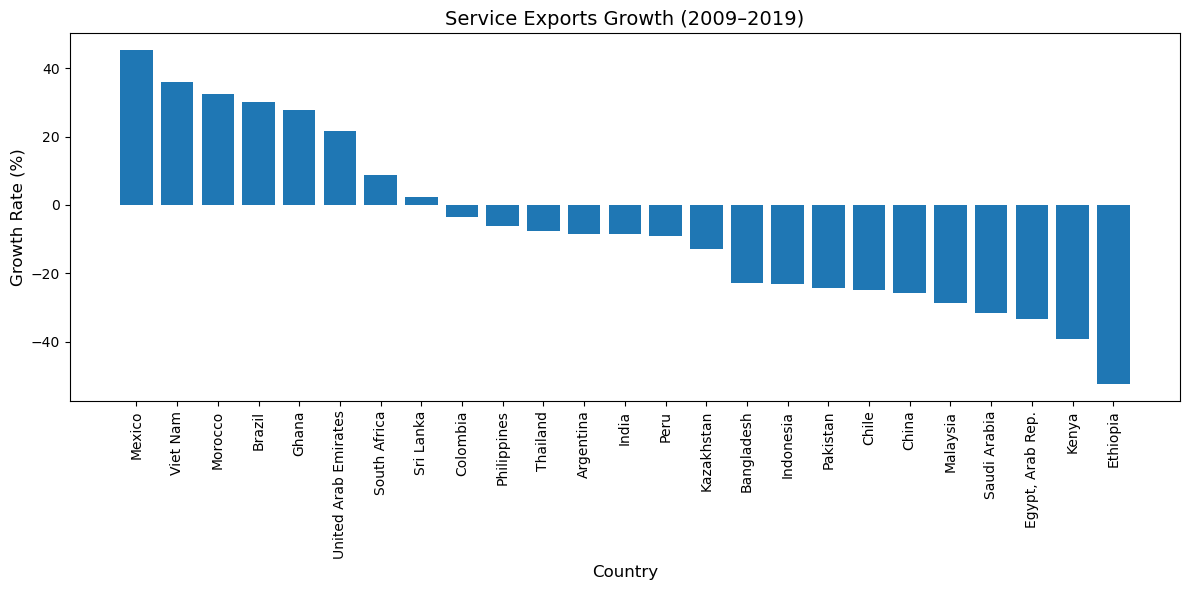

In [92]:
growth = df_reset[df_reset['year'].isin([2009, 2019])]
growth = growth.pivot(index='country', columns='year', values='service_export')
growth['growth_rate'] = ((growth[2019] - growth[2009]) / growth[2009]) * 100
growth = growth.sort_values('growth_rate', ascending=False)

plt.figure(figsize=(12,6))
plt.bar(growth.index, growth['growth_rate'])
plt.title("Service Exports Growth (2009–2019)", fontsize=14)
plt.ylabel("Growth Rate (%)", fontsize=12)
plt.xlabel("Country", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

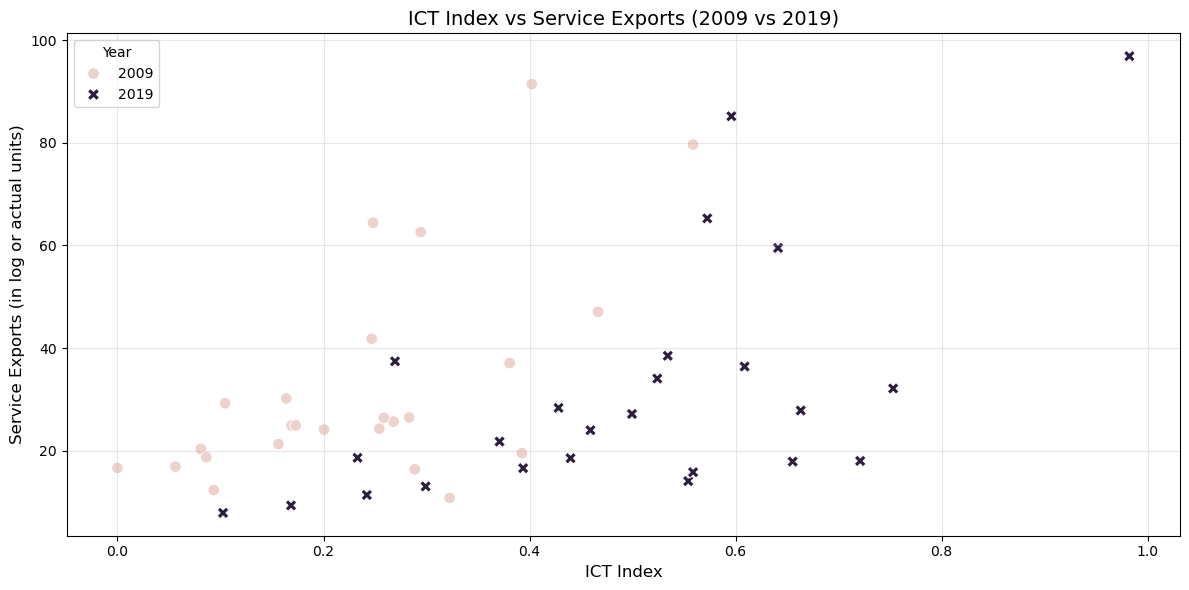

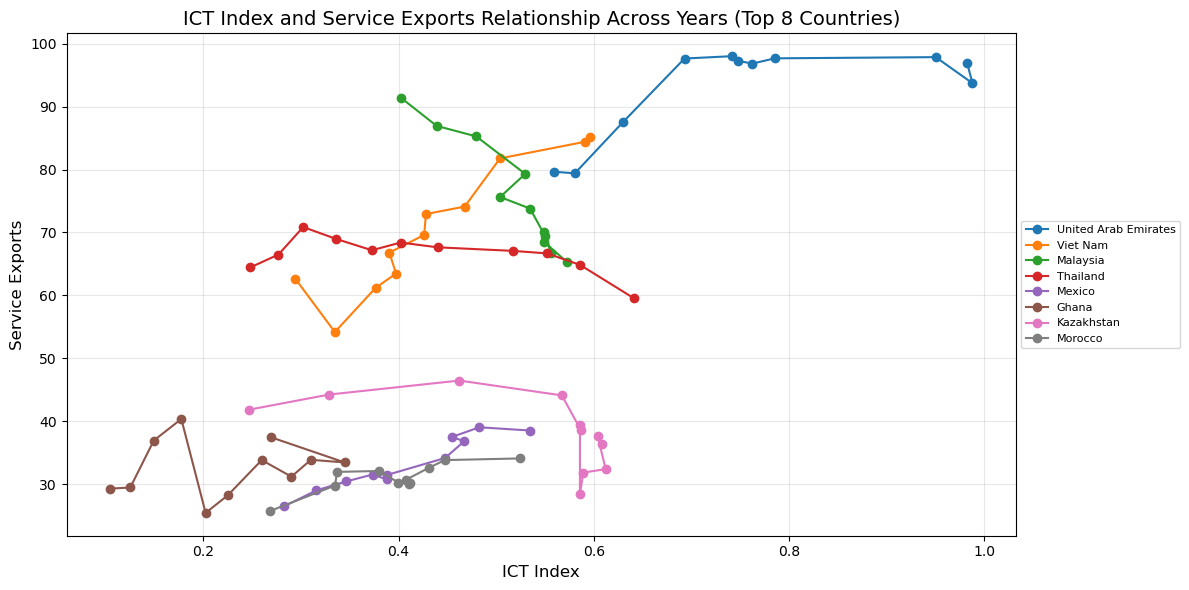


--- CORRELATION BETWEEN ICT INDEX AND SERVICE EXPORTS BY COUNTRY ---

                 country    level_1  corr_ict_service
14                Mexico  ict_index          0.961558
24              Viet Nam  ict_index          0.932683
15               Morocco  ict_index          0.797728
2                 Brazil  ict_index          0.741787
20          South Africa  ict_index          0.712787
23  United Arab Emirates  ict_index          0.670235
21             Sri Lanka  ict_index          0.185277
8                  Ghana  ict_index          0.157694
18           Philippines  ict_index         -0.320999
17                  Peru  ict_index         -0.453785
9                  India  ict_index         -0.510066
5               Colombia  ict_index         -0.517205
22              Thailand  ict_index         -0.549813
11            Kazakhstan  ict_index         -0.567494
6       Egypt, Arab Rep.  ict_index         -0.687430
0              Argentina  ict_index         -0.703388
1          

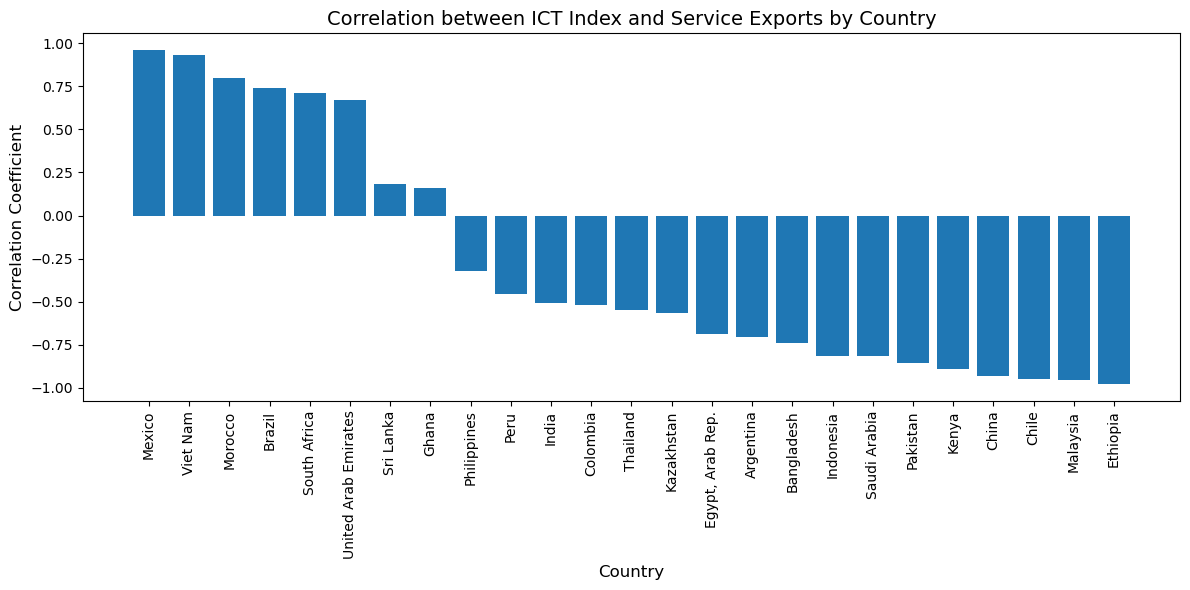

In [94]:

# ICT INDEX EFFECT ON SERVICE EXPORTS (ACROSS YEARS & COUNTRIES)

import seaborn as sns

# Reset index for plotting
df_reset = df.reset_index()

# --- (A) Scatter Plot: ICT vs Service Exports for Selected Years ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_reset[df_reset['year'].isin([2009, 2019])],
                x='ict_index', y='service_export', hue='year', style='year', s=70)
plt.title("ICT Index vs Service Exports (2009 vs 2019)", fontsize=14)
plt.xlabel("ICT Index", fontsize=12)
plt.ylabel("Service Exports (in log or actual units)", fontsize=12)
plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- (B) Country-wise Relationship Over Time (Trend Lines) ---
plt.figure(figsize=(12, 6))

# Select top 8 countries for readability (by 2019 service exports)
top_countries = (
    df_reset[df_reset['year'] == 2019]
    .sort_values('service_export', ascending=False)['country']
    .head(8)
)

for country in top_countries:
    temp = df_reset[df_reset['country'] == country]
    plt.plot(temp['ict_index'], temp['service_export'], marker='o', label=country)

plt.title("ICT Index and Service Exports Relationship Across Years (Top 8 Countries)", fontsize=14)
plt.xlabel("ICT Index", fontsize=12)
plt.ylabel("Service Exports", fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- (C) Correlation Analysis by Country ---
corr_by_country = df_reset.groupby('country')[['ict_index', 'service_export']].corr().iloc[0::2,-1]
corr_by_country = corr_by_country.reset_index().rename(columns={'service_export':'corr_ict_service'})
corr_by_country = corr_by_country.sort_values('corr_ict_service', ascending=False)

print("\n--- CORRELATION BETWEEN ICT INDEX AND SERVICE EXPORTS BY COUNTRY ---\n")
print(corr_by_country)

# --- (D) Optional: Plot Correlation by Country ---
plt.figure(figsize=(12,6))
plt.bar(corr_by_country['country'], corr_by_country['corr_ict_service'])
plt.xticks(rotation=90)
plt.title("Correlation between ICT Index and Service Exports by Country", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Correlation Coefficient", fontsize=12)
plt.tight_layout()
plt.show()



<Figure size 1200x600 with 0 Axes>

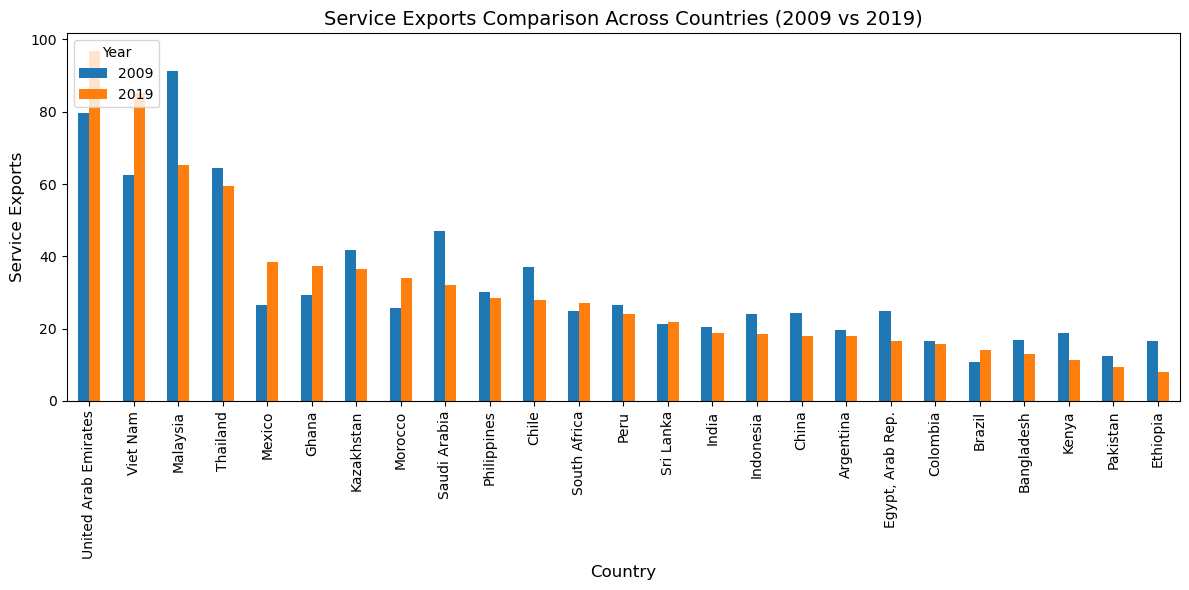

In [95]:

# SERVICE EXPORTS COMPARISON (2009 vs 2019 ACROSS COUNTRIES)

# Reset index for easier manipulation
df_reset = df.reset_index()

# Filter for 2009 and 2019
service_compare = df_reset[df_reset['year'].isin([2009, 2019])]

# Pivot table for bar plot
service_pivot = service_compare.pivot(index='country', columns='year', values='service_export').dropna()

# Sort countries by 2019 service exports (highest to lowest)
service_pivot = service_pivot.sort_values(by=2019, ascending=False)

# Plot side-by-side comparison bar chart
plt.figure(figsize=(12,6))
service_pivot.plot(kind='bar', figsize=(12,6))
plt.title("Service Exports Comparison Across Countries (2009 vs 2019)", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Service Exports", fontsize=12)
plt.legend(title="Year", loc='upper left')
plt.tight_layout()
plt.show()



--- TOP 10 COUNTRIES WITH HIGHEST SERVICE EXPORT GROWTH (2009–2019) ---

year                  growth_rate_%
country                            
Mexico                        45.32
Viet Nam                      36.02
Morocco                       32.57
Brazil                        30.15
Ghana                         27.85
United Arab Emirates          21.60
South Africa                   8.88
Sri Lanka                      2.32
Colombia                      -3.39
Philippines                   -6.08


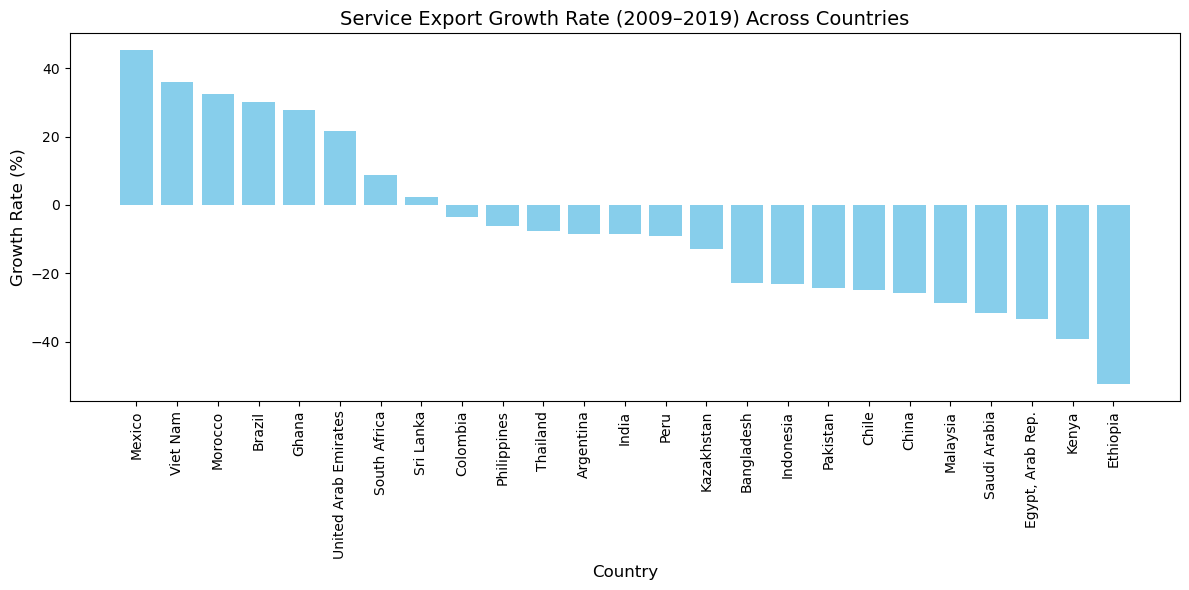

In [96]:

# SERVICE EXPORTS GROWTH (2009–2019)


# Calculate growth rate (%) between 2009 and 2019
service_pivot['growth_rate_%'] = ((service_pivot[2019] - service_pivot[2009]) / service_pivot[2009]) * 100

# Sort by growth rate
growth_sorted = service_pivot.sort_values('growth_rate_%', ascending=False)

# Display top 10 countries with highest growth
print("\n--- TOP 10 COUNTRIES WITH HIGHEST SERVICE EXPORT GROWTH (2009–2019) ---\n")
print(growth_sorted[['growth_rate_%']].head(10).round(2))

# Bar plot for growth comparison
plt.figure(figsize=(12,6))
plt.bar(growth_sorted.index, growth_sorted['growth_rate_%'], color='skyblue')
plt.xticks(rotation=90)
plt.title("Service Export Growth Rate (2009–2019) Across Countries", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Growth Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()

In [99]:
model_with_gdp = PanelOLS.from_formula(
    'log_service_export ~ ict_index + log_gdp + log_population + EntityEffects + TimeEffects',
    data=df
).fit(cov_type='robust')
print(model_with_gdp.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     log_service_export   R-squared:                        0.1222
Estimator:                   PanelOLS   R-squared (Between):             -81.160
No. Observations:                 275   R-squared (Within):               0.2152
Date:                Mon, Oct 27 2025   R-squared (Overall):             -81.003
Time:                        10:49:39   Log-likelihood                    196.15
Cov. Estimator:                Robust                                           
                                        F-statistic:                      10.998
Entities:                          25   P-value                           0.0000
Avg Obs:                       11.000   Distribution:                   F(3,237)
Min Obs:                       11.000                                           
Max Obs:                       11.000   F-statistic (robust):             7.9756
                            

In [100]:
model_without_gdp = PanelOLS.from_formula(
    'log_service_export ~ ict_index + log_population + EntityEffects + TimeEffects',
    data=df
).fit(cov_type='robust')
print(model_without_gdp.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:     log_service_export   R-squared:                        0.0471
Estimator:                   PanelOLS   R-squared (Between):             -34.261
No. Observations:                 275   R-squared (Within):               0.1211
Date:                Mon, Oct 27 2025   R-squared (Overall):             -34.195
Time:                        10:50:24   Log-likelihood                    184.87
Cov. Estimator:                Robust                                           
                                        F-statistic:                      5.8879
Entities:                          25   P-value                           0.0032
Avg Obs:                       11.000   Distribution:                   F(2,238)
Min Obs:                       11.000                                           
Max Obs:                       11.000   F-statistic (robust):             3.4529
                            